# Week 8 — Policy Gradients and PPO

Letting the algorithm search · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/w08-ppo/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

This lab **trains** and takes a few minutes to run. That is normal.

## Today we finally train something

Last week we wrote the problem. Today we search it.

Deliberately, **we do not start with the humanoid.** We start with a
cart and a pole, because you need to know what a *healthy* learning
curve looks like before you can diagnose a sick one.

By the end of the lecture we will point PPO at the G1 — and watch it get
**worse**. That is the intended result, and it names next week.

------------------------------------------------------------------------

## The idea

We want $\theta$ maximising
$J(\theta) = \mathbb{E}_{\tau\sim\pi_\theta}[R(\tau)]$.

The problem: the environment is not differentiable. We cannot
backpropagate through contact, friction, or a physics engine.

The **policy gradient theorem** goes around it:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_t \nabla_\theta \log \pi_\theta(a_t\mid s_t)\; R_t\right]$$

Read it as an instruction: **make the actions that preceded high return
more likely.** The gradient touches only the policy network, never the
simulator.

------------------------------------------------------------------------

## REINFORCE, in full

That equation is about twenty lines of code.

In [1]:
try:
    import soc4180
    import torch
except ImportError:
    %pip install -q "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180, torch

import time, warnings
import numpy as np
import torch.nn as nn
import gymnasium as gym
warnings.filterwarnings("ignore")

torch.manual_seed(0); np.random.seed(0)
env = gym.make("CartPole-v1")
policy = nn.Sequential(nn.Linear(4, 64), nn.Tanh(), nn.Linear(64, 2))
opt = torch.optim.Adam(policy.parameters(), lr=1e-2)

def episode():
    obs, _ = env.reset(); logps, rewards = [], []
    while True:
        dist = torch.distributions.Categorical(
            logits=policy(torch.as_tensor(obs, dtype=torch.float32)))
        action = dist.sample()
        logps.append(dist.log_prob(action))
        obs, r, terminated, truncated, _ = env.step(int(action))
        rewards.append(r)
        if terminated or truncated:
            return torch.stack(logps), rewards

def discounted(rewards, gamma=0.99):
    R, out = 0.0, []
    for r in reversed(rewards):
        R = r + gamma * R; out.append(R)
    return torch.tensor(list(reversed(out)), dtype=torch.float32)

------------------------------------------------------------------------

## Training it

In [2]:
env.reset(seed=0); env.action_space.seed(0)
t0 = time.time(); history = []

for update in range(100):
    logps, returns = [], []
    for _ in range(8):                          # a batch of episodes per update
        lp, rewards = episode()
        logps.append(lp); returns.append(discounted(rewards))
        history.append(sum(rewards))

    lp = torch.cat(logps); ret = torch.cat(returns)
    ret = (ret - ret.mean()) / (ret.std() + 1e-8)      # baseline: centre the returns

    loss = -(lp * ret).mean()                   # ascend the gradient
    opt.zero_grad(); loss.backward(); opt.step()

print(f"{len(history)} episodes in {time.time()-t0:.0f}s")
for k in (100, 300, 500, len(history)):
    print(f"  by episode {k:3d}: mean return over the previous 50 = {np.mean(history[k-50:k]):6.1f}")

800 episodes in 173s
  by episode 100: mean return over the previous 50 =   60.0
  by episode 300: mean return over the previous 50 =  381.2
  by episode 500: mean return over the previous 50 =  486.9
  by episode 800: mean return over the previous 50 =  488.6

Two details carry this. **Returns are centred** — subtracting the mean
is a *baseline*, and without it the thing barely moves. And updates use
a **batch of eight episodes**: with one episode per update the variance
is so large that training frequently goes nowhere at all.

------------------------------------------------------------------------

## Look at the curve, not the last number

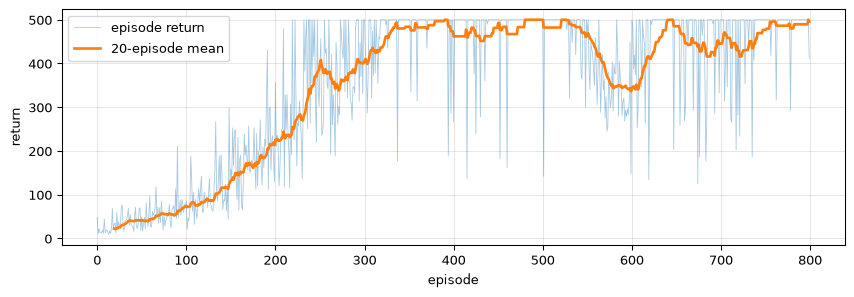

In [3]:
import matplotlib.pyplot as plt

smooth = np.convolve(history, np.ones(20)/20, mode="valid")
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(history, lw=0.6, alpha=0.4, label="episode return")
ax.plot(np.arange(len(smooth)) + 19, smooth, lw=2, label="20-episode mean")
ax.set_xlabel("episode"); ax.set_ylabel("return"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

It climbs, but raggedly, and it dips. **That is not a bug — it is
REINFORCE.** The gradient is estimated from a handful of trajectories,
so it is noisy, and an unlucky batch can undo real progress.

Try it with a batch of one and you will often see no learning
whatsoever. The algorithm is correct; the estimator is just terrible.

------------------------------------------------------------------------

## Reducing the variance

Three fixes, in the order the field found them:

1.  **Baseline.** Subtract $b(s)$ from the return. It does not bias the
    gradient and cuts variance sharply. We used the batch mean; a
    learned value function $V(s)$ is better.
2.  **Advantage.** With $V(s)$ learned, use $A_t = R_t - V(s_t)$: “was
    this action better than average *from here*?” That is
    **actor-critic**.
3.  **Reuse the data.** REINFORCE throws each trajectory away after one
    gradient step. That is wasteful when each step costs a physics
    simulation.

Reusing data is dangerous: after a few updates the policy no longer
matches the data that was collected. **PPO exists to make that reuse
safe.**

------------------------------------------------------------------------

## PPO in one slide

Let
$r_t(\theta) = \dfrac{\pi_\theta(a_t\mid s_t)}{\pi_{\theta_{\text{old}}}(a_t\mid s_t)}$
— how much the new policy has changed its mind.

$$L = \mathbb{E}\left[\min\left(r_t A_t,\;\ \text{clip}(r_t, 1-\epsilon, 1+\epsilon)\,A_t\right)\right]$$

The clip removes any incentive to push $r_t$ beyond $1\pm\epsilon$: once
an action is far enough more likely, making it *more* likely buys
nothing.

**Small, safe steps, taken many times.** That is the entire idea, and it
is why PPO is the default for locomotion.

------------------------------------------------------------------------

## PPO on a continuous task

CartPole has two discrete actions. A robot has twelve continuous ones,
so let us move to a continuous problem — still trivial, but the right
shape.

In [4]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

t0 = time.time()
pend = gym.make("InvertedPendulum-v5")
model = PPO("MlpPolicy", pend, verbose=0, seed=0, device="cpu")
before, _ = evaluate_policy(model, pend, n_eval_episodes=10, warn=False)
model.learn(total_timesteps=80_000)
after, _ = evaluate_policy(model, pend, n_eval_episodes=10, warn=False)
print(f"InvertedPendulum: return {before:.1f} -> {after:.1f}  ({time.time()-t0:.0f}s)")

InvertedPendulum: return 25.7 -> 1000.0  (99s)

Solved, cleanly, in about a minute and a half. **Remember this
feeling.**

------------------------------------------------------------------------

## Now the humanoid

Same algorithm, same defaults, our environment from last week.

In [5]:
from soc4180.envs import G1WalkEnv

env_g1 = G1WalkEnv()
t0 = time.time()
agent = PPO("MlpPolicy", env_g1, verbose=0, seed=0, device="cpu")
before, _ = evaluate_policy(agent, env_g1, n_eval_episodes=5, warn=False)
print(f"untrained : {before:7.1f}      (hold-the-crouch baseline = 774)")
agent.learn(total_timesteps=30_000)
after, _ = evaluate_policy(agent, env_g1, n_eval_episodes=5, warn=False)
print(f"30k steps : {after:7.1f}      ({time.time()-t0:.0f}s)")

untrained :   774.3      (hold-the-crouch baseline = 774)
30k steps :    94.7      (69s)

Two things in those numbers, and both matter.

------------------------------------------------------------------------

## The untrained policy already scores 774

That is exactly the “do nothing” baseline from Week 7 — and it is **by
design**.

Residual actions mean an untrained network, whose outputs hover near
zero, commands the nominal crouch. It stands there, collects the alive
bonus and the upright reward, and scores well.

That is the Week 7 action-design decision paying off: **the policy
starts from competence rather than from a heap on the floor.**

It also sets a cruel bar. Any learning must beat 774, and the easiest
way to score 774 is to do nothing at all.

------------------------------------------------------------------------

## Training made it worse

774 → 95. **Thirty thousand steps of learning produced a policy far
worse than the untrained one.** Look at what it actually does:

In [6]:
obs, _ = env_g1.reset(seed=0); steps = 0
while True:
    action, _ = agent.predict(obs, deterministic=True)
    obs, r, terminated, truncated, info = env_g1.step(action)
    steps += 1
    if terminated or truncated:
        break
print(f"steps survived   : {steps} of {env_g1.max_steps}")
print(f"travelled        : {env_g1.data.qpos[0]:+.3f} m")
print(f"forward velocity : {info['forward_velocity']:+.3f} m/s  "
      f"(the reward asks for {env_g1.target_velocity})")
print(f"outcome          : {'FELL' if terminated else 'survived'}")

steps survived   : 46 of 500
travelled        : +0.478 m
forward velocity : +1.283 m/s  (the reward asks for 0.5)
outcome          : FELL

It **lunges**. Velocity far past the target, a metre of ground covered,
and then it goes down.

------------------------------------------------------------------------

## Read the failure carefully

This is not PPO failing. PPO did exactly what we asked.

Our reward pays for tracking forward velocity. Diving forward earns that
immediately. Falling costs the alive bonus — but only *later*, and
$\gamma < 1$ means later is worth less.

> The policy found a genuinely higher-scoring behaviour under our reward
> function, and our reward function was wrong.

**A learning algorithm is a search for loopholes in your
specification.** It is extremely good at that, and it has no idea you
wanted walking.

------------------------------------------------------------------------

## What would fix it

Nothing today. But the shape of the answer:

| Problem                | Fix                                    | Week |
|------------------------|----------------------------------------|------|
| Diving beats walking   | reward terms that penalise the exploit | 9    |
| 30k steps is nothing   | 10⁸ steps, in parallel, on a GPU       | 10   |
| One brittle solution   | randomise the world it trains in       | 11   |
| Only works in this sim | measure the gap deliberately           | 12   |

Locomotion policies in the literature train for **150–200 million**
steps. We ran thirty thousand — about 0.02% of a real run. Even a
correct reward would show little here.

**Both problems are real, and they are different problems.** Next week
fixes the reward; the week after buys the compute.

------------------------------------------------------------------------

## Exercises

1.  **No baseline.** Delete the return standardisation from REINFORCE.
    How much worse is it? Explain via variance rather than bias.
2.  **Discount.** Set $\gamma = 0.9$ and $\gamma = 0.999$ on CartPole.
    Which trains faster and which reaches a better final policy?
3.  **Clipping.** Train the humanoid with `clip_range=0.05` and
    `clip_range=0.5`. Does either stop the lunging? Why is that the
    wrong tool for this problem?
4.  **Kill the exploit.** Cap the tracking reward so exceeding the
    target velocity earns nothing extra. Retrain for 30k steps. Does the
    lunge disappear, and what replaces it?
5.  **Alive bonus.** Sweep the bonus from 0 to 2. Find the value at
    which standing still beats every attempt to walk. What does that say
    about shaping?
6.  **Honest baselines.** Report untrained return, hold-the-crouch
    return, and trained return for three seeds. Is the difference
    between them significant?

------------------------------------------------------------------------

## Next week

**Week 9 — reward shaping.** We take a real locomotion reward apart term
by term, remove them one at a time, and catalogue the pathology each one
produces.

Today’s lunging robot is the first entry in that catalogue.